<a href="https://colab.research.google.com/github/FinestMaximus/mrkt_screener/blob/main/Screening_Stocks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Getting Requirements**

In [ ]:
! pip install matplotlib yfinance pandas mplfinance marketprofile plotly dash

# **Imports**

In [25]:
from datetime import datetime, timedelta

import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

import mplfinance as mpf
import numpy as np
import pandas as pd
import pandas_datareader as pdr
import yfinance as yf
from IPython.display import Markdown, display
from plotly.subplots import make_subplots

from market_profile import MarketProfile


# **Initial Companies**

In [128]:
companies = ['AMZN', 'GOOG', 'WMT', 'TSLA', 'META', 'NVDA', 'GOLD', 'GSAT', 'AMD',
             'ASML', 'BHP', 'NFLX', 'AAPL', 'AMUN.PA', 'STM', 'LUV', 'TKA.DE', 'IFX.DE',
             'ERA.PA', 'VK.PA', 'MTTR', 'EDF', 'ASTR', 'NIO', 'SGML', 'U',
             'OKTA', 'SSSS', 'PANW', 'TDOC', 'DARK.L', 'PL', 'IRDM', 'JBLU', 'BTC-USD', 'ETH-USD',
             'DOGE-USD', 'TSM', 'FSLR', 'RAYS', 'ICLN', 'ENB', 'NEE', 'ALB', 'DIS', 'TMUS',
             'VZ', 'CMCSA', 'T', 'NTES', 'AMX', 'SPIR', 'ASTS', 'SPCE', 'RKLB',
             'STLA', 'MSFT', 'QCOM', 'ARM', 'CRWD', 'ANET', 'CRM', 'IBM', 'INTC', 'ORCL', 'NOW',
             'ADBE', 'WDAY', 'AVGO', 'NET', 'MRVL', 'ZM', 'SNOW', 'TEAM', 'ACN', 'EPAM', 'COIN',
             'PLUG', 'IMBBY', 'PII', 'CPB', 'MDT', 'RTX', 'USB', 'NIO']

# 2222.SR, LCID,  'LUNR', 'LLAP',

# **Parametters**

In [129]:
interval_dates = '3mo' ### each candle is a quarter
days_history = 365*5 ### looking 5 years back, and 5 years forward
eps_threshold = 5 ### interested in high revenue companies
gross_margin_threshold = 20 ### minimum acceptable gross margin

# **Data fetching and preparation**

In [130]:
def fetch_historical_data(ticker, start_date, end_date, period=None, interval=interval_dates):
    try:
        if period:
            data = ticker.history(period=period, interval=interval)
        else:
            data = ticker.history(start=start_date, end=end_date, interval=interval)
        return data
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return pd.DataFrame()  # Return an empty DataFrame

def fetch_data(companies):
    tickers = yf.Tickers(' '.join(companies))
    start_date_str, end_date_str = get_date_range()
    metrics = {
        'eps_values': [],
        'pe_values': [],
        'market_caps': [],
        'peg_values':[],
        'ps_values':[],
        'pb_values':[],
        'company_labels': [],
        'price_diff': {},
        # 'recommendations': [],  # Add this line to store recommendation data
        'recommendations_summary': [],  # Add this line to store recommendation data
        'upgrades_downgrades': [],  # Add this line to store recommendation data
        'gross_margins': []
    }
    industries = classify_by_industry(tickers)

    price_diff = calculate_price_diff(companies)
    metrics['price_diff'] = price_diff

    for company in companies:
        ticker = tickers.tickers[company]
        data = fetch_historical_data(ticker, start_date_str, end_date_str)
        if not data.empty:
            populate_metrics(ticker, metrics)

    return industries, metrics

def calculate_price_diff(companies):
    tickers = yf.Tickers(' '.join(companies))
    price_diff = {}  # Store price difference info here

    for company in companies:
        ticker = tickers.tickers[company]
        hist = fetch_historical_data(ticker, None, None, period="1y")
        if not hist.empty:
            today_price = hist['Close'].iloc[-1]
            high_52week = max(hist['High'])
            low_52week = min(hist['Low'])
            high_percent_diff = ((today_price - high_52week) / high_52week) * 100
            low_percent_diff = ((today_price - low_52week) / low_52week) * 100
            price_diff[company] = {'high_diff': -1 * high_percent_diff, 'low_diff': low_percent_diff}

    return price_diff

def populate_metrics(ticker, metrics):
    stock_info = ticker.info
    eps = stock_info.get('trailingEps', 0)
    pe = stock_info.get('trailingPE', 0)
    peg = stock_info.get('pegRatio', 0)
    ps = stock_info.get('priceToSalesTrailing12Months', 0)
    pb = stock_info.get('priceToBook', 0)
    market_cap = stock_info.get('marketCap', 0)
    gross_margin = stock_info.get('grossMargins', 0)  # This line fetches the gross margin
    # recommendation = fetch_recommendations(ticker)  # Fetch the recommendation
    recommendations_summary = fetch_recommendations_summary(ticker)
    upgrades_downgrades = fetch_upgrades_downgrades(ticker)

    metrics['eps_values'].append(eps)
    metrics['pe_values'].append(pe)
    metrics['peg_values'].append(peg)
    metrics['ps_values'].append(ps)
    metrics['pb_values'].append(pb)
    metrics['market_caps'].append(market_cap)
    metrics['company_labels'].append(ticker.ticker)
    metrics['gross_margins'].append(gross_margin)  # And this line adds it to your metrics dictionary
    # metrics['recommendations'].append(recommendation)  # Add it to your metrics
    metrics['recommendations_summary'].append(recommendations_summary)  # Add it to your metrics
    metrics['upgrades_downgrades'].append(upgrades_downgrades)  # Add it to your metrics

def get_date_range(days_back=days_history):
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    return start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')

def classify_by_industry(tickers):
    industries = {}
    for ticker in tickers.tickers.values():
        try:
            sector = ticker.info['sector']
        except KeyError:
            continue
        industries.setdefault(sector, []).append(ticker)
    return industries

def fetch_recommendations(ticker):
    try:
        rec_data = ticker.get_recommendations()
        if not rec_data.empty:
            # print(rec_data)
            return rec_data
        else:
            return "No recommendation"
    except Exception as e:
        return "Error"

def fetch_recommendations_summary(ticker):
    try:
        rec_data = ticker.get_recommendations_summary()
        if not rec_data.empty:
            # Initialize an empty dictionary to hold the structured recommendation data
            structured_rec_data = {}

            # Iterate through each row in the DataFrame to organize the data by period
            for index, row in rec_data.iterrows():
                period = row['period']  # Assuming 'period' is a column in your DataFrame

                # Create a nested dictionary for each period with recommendation data
                structured_rec_data[period] = {
                    'strongBuy': row['strongBuy'],
                    'buy': row['buy'],
                    'hold': row['hold'],
                    'sell': row['sell'],
                    'strongSell': row['strongSell']
                }

            print(ticker)  # Print the ticker object
            print(structured_rec_data)  # Print the structured data

            return structured_rec_data
        else:
            return "No recommendation data available."
    except Exception as e:
        return f"Error: {str(e)}"

def fetch_upgrades_downgrades(ticker):
    try:
        rec_data = ticker.get_upgrades_downgrades()
        if not rec_data.empty:
            # print(rec_data)
            return rec_data
        else:
            return "No recommendation"
    except Exception as e:
        return "Error"

def calculate_market_profile(data):
    mp = MarketProfile(data)
    mp_slice = mp[data.index.min():data.index.max()]

    # Access the attributes you're interested in
    va_high, va_low = mp_slice.value_area
    poc_price = mp_slice.poc_price  # Point of control price
    profile_range = mp_slice.profile_range

    return va_high, va_low, poc_price, profile_range

def plot_sector_distribution_interactive(industries):
    # Calculate total tickers per sector
    sector_counts = {sector: len(tickers) for sector, tickers in industries.items()}

    # Data for plotting
    labels = list(sector_counts.keys())
    sizes = list(sector_counts.values())

    # Create the pie chart
    fig = go.Figure(data=[go.Pie(labels=labels, values=sizes, hole=.3)])

    # Customizing the plot
    fig.update_layout(
        title_text="Interactive Ticker Distribution by Sector",
        # Add annotations in the center of the donut pies.
        annotations=[dict(text='Sectors', x=0.50, y=0.5, font_size=20, showarrow=False)]
    )

    # Show plot
    fig.show()

start_date_str, end_date_str = get_date_range()
industries, metrics = fetch_data(companies)

yfinance.Ticker object <AMZN>
{'0m': {'strongBuy': 15, 'buy': 28, 'hold': 3, 'sell': 1, 'strongSell': 0}, '-1m': {'strongBuy': 18, 'buy': 37, 'hold': 1, 'sell': 0, 'strongSell': 0}, '-2m': {'strongBuy': 17, 'buy': 36, 'hold': 1, 'sell': 0, 'strongSell': 0}, '-3m': {'strongBuy': 19, 'buy': 35, 'hold': 3, 'sell': 1, 'strongSell': 0}}
yfinance.Ticker object <GOOG>
{'0m': {'strongBuy': 2, 'buy': 3, 'hold': 0, 'sell': 0, 'strongSell': 0}, '-1m': {'strongBuy': 6, 'buy': 5, 'hold': 2, 'sell': 0, 'strongSell': 0}, '-2m': {'strongBuy': 6, 'buy': 5, 'hold': 2, 'sell': 0, 'strongSell': 0}, '-3m': {'strongBuy': 5, 'buy': 4, 'hold': 2, 'sell': 0, 'strongSell': 0}}
yfinance.Ticker object <WMT>
{'0m': {'strongBuy': 8, 'buy': 7, 'hold': 15, 'sell': 1, 'strongSell': 1}, '-1m': {'strongBuy': 12, 'buy': 24, 'hold': 5, 'sell': 0, 'strongSell': 0}, '-2m': {'strongBuy': 12, 'buy': 25, 'hold': 5, 'sell': 0, 'strongSell': 0}, '-3m': {'strongBuy': 11, 'buy': 20, 'hold': 8, 'sell': 0, 'strongSell': 0}}
yfinance

ERROR:yfinance:404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/AMUN.PA?modules=upgradeDowngradeHistory&corsDomain=finance.yahoo.com&formatted=false&symbol=AMUN.PA&crumb=nWABEP5izBL


yfinance.Ticker object <STM>
{'0m': {'strongBuy': 1, 'buy': 2, 'hold': 2, 'sell': 1, 'strongSell': 0}, '-1m': {'strongBuy': 3, 'buy': 5, 'hold': 2, 'sell': 1, 'strongSell': 0}, '-2m': {'strongBuy': 3, 'buy': 5, 'hold': 2, 'sell': 1, 'strongSell': 0}, '-3m': {'strongBuy': 2, 'buy': 3, 'hold': 3, 'sell': 0, 'strongSell': 0}}
yfinance.Ticker object <LUV>
{'0m': {'strongBuy': 7, 'buy': 9, 'hold': 3, 'sell': 0, 'strongSell': 0}, '-1m': {'strongBuy': 0, 'buy': 4, 'hold': 11, 'sell': 3, 'strongSell': 2}, '-2m': {'strongBuy': 0, 'buy': 4, 'hold': 12, 'sell': 3, 'strongSell': 1}, '-3m': {'strongBuy': 4, 'buy': 13, 'hold': 4, 'sell': 0, 'strongSell': 0}}
yfinance.Ticker object <TKA.DE>
{'0m': {'strongBuy': 0, 'buy': 0, 'hold': 0, 'sell': 0, 'strongSell': 0}, '-1m': {'strongBuy': 0, 'buy': 0, 'hold': 0, 'sell': 0, 'strongSell': 0}, '-2m': {'strongBuy': 0, 'buy': 0, 'hold': 0, 'sell': 0, 'strongSell': 0}, '-3m': {'strongBuy': 0, 'buy': 0, 'hold': 0, 'sell': 0, 'strongSell': 0}}


ERROR:yfinance:404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/TKA.DE?modules=upgradeDowngradeHistory&corsDomain=finance.yahoo.com&formatted=false&symbol=TKA.DE&crumb=nWABEP5izBL


yfinance.Ticker object <IFX.DE>
{'0m': {'strongBuy': 0, 'buy': 0, 'hold': 0, 'sell': 0, 'strongSell': 0}, '-1m': {'strongBuy': 0, 'buy': 0, 'hold': 0, 'sell': 0, 'strongSell': 0}, '-2m': {'strongBuy': 0, 'buy': 0, 'hold': 0, 'sell': 0, 'strongSell': 0}, '-3m': {'strongBuy': 0, 'buy': 0, 'hold': 0, 'sell': 0, 'strongSell': 0}}


...

yfinance.Ticker object <PL>
{'0m': {'strongBuy': 0, 'buy': 0, 'hold': 0, 'sell': 0, 'strongSell': 0}, '-1m': {'strongBuy': 2, 'buy': 7, 'hold': 2, 'sell': 0, 'strongSell': 0}, '-2m': {'strongBuy': 2, 'buy': 7, 'hold': 2, 'sell': 0, 'strongSell': 0}, '-3m': {'strongBuy': 0, 'buy': 0, 'hold': 0, 'sell': 0, 'strongSell': 0}}
yfinance.Ticker object <IRDM>
{'0m': {'strongBuy': 3, 'buy': 2, 'hold': 3, 'sell': 0, 'strongSell': 0}, '-1m': {'strongBuy': 2, 'buy': 5, 'hold': 0, 'sell': 0, 'strongSell': 0}, '-2m': {'strongBuy': 2, 'buy': 5, 'hold': 0, 'sell': 0, 'strongSell': 0}, '-3m': {'strongBuy': 1, 'buy': 3, 'hold': 2, 'sell': 0, 'strongSell': 0}}
yfinance.Ticker object <JBLU>
{'0m': {'strongBuy': 1, 'buy': 5, 'hold': 9, 'sell': 0, 'strongSell': 1}, '-1m': {'strongBuy': 0, 'buy': 1, 'hold': 8, 'sell': 4, 'strongSell': 1}, '-2m': {'strongBuy': 0, 'buy': 1, 'hold': 9, 'sell': 3, 'strongSell': 1}, '-3m': {'strongBuy': 1, 'buy': 8, 'hold': 5, 'sell': 1, 'strongSell': 1}}


ERROR:yfinance:404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/BTC-USD?modules=recommendationTrend&corsDomain=finance.yahoo.com&formatted=false&symbol=BTC-USD&crumb=nWABEP5izBL
ERROR:yfinance:404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/BTC-USD?modules=upgradeDowngradeHistory&corsDomain=finance.yahoo.com&formatted=false&symbol=BTC-USD&crumb=nWABEP5izBL
ERROR:yfinance:404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/ETH-USD?modules=recommendationTrend&corsDomain=finance.yahoo.com&formatted=false&symbol=ETH-USD&crumb=nWABEP5izBL
ERROR:yfinance:404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/ETH-USD?modules=upgradeDowngradeHistory&corsDomain=finance.yahoo.com&formatted=false&symbol=ETH-USD&crumb=nWABEP5izBL
ERROR:yfinance:404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance

yfinance.Ticker object <TSM>
{'0m': {'strongBuy': 1, 'buy': 0, 'hold': 5, 'sell': 0, 'strongSell': 0}, '-1m': {'strongBuy': 5, 'buy': 6, 'hold': 1, 'sell': 0, 'strongSell': 0}, '-2m': {'strongBuy': 5, 'buy': 7, 'hold': 1, 'sell': 0, 'strongSell': 0}, '-3m': {'strongBuy': 1, 'buy': 1, 'hold': 5, 'sell': 0, 'strongSell': 0}}
yfinance.Ticker object <FSLR>
{'0m': {'strongBuy': 3, 'buy': 6, 'hold': 8, 'sell': 0, 'strongSell': 0}, '-1m': {'strongBuy': 6, 'buy': 17, 'hold': 6, 'sell': 0, 'strongSell': 0}, '-2m': {'strongBuy': 6, 'buy': 18, 'hold': 6, 'sell': 0, 'strongSell': 0}, '-3m': {'strongBuy': 4, 'buy': 4, 'hold': 11, 'sell': 3, 'strongSell': 0}}


ERROR:yfinance:404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/RAYS?modules=recommendationTrend&corsDomain=finance.yahoo.com&formatted=false&symbol=RAYS&crumb=nWABEP5izBL
ERROR:yfinance:404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/RAYS?modules=upgradeDowngradeHistory&corsDomain=finance.yahoo.com&formatted=false&symbol=RAYS&crumb=nWABEP5izBL
ERROR:yfinance:404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/ICLN?modules=recommendationTrend&corsDomain=finance.yahoo.com&formatted=false&symbol=ICLN&crumb=nWABEP5izBL
ERROR:yfinance:404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/ICLN?modules=upgradeDowngradeHistory&corsDomain=finance.yahoo.com&formatted=false&symbol=ICLN&crumb=nWABEP5izBL


yfinance.Ticker object <ENB>
{'0m': {'strongBuy': 1, 'buy': 5, 'hold': 6, 'sell': 0, 'strongSell': 0}, '-1m': {'strongBuy': 1, 'buy': 8, 'hold': 6, 'sell': 1, 'strongSell': 1}, '-2m': {'strongBuy': 1, 'buy': 7, 'hold': 5, 'sell': 1, 'strongSell': 1}, '-3m': {'strongBuy': 1, 'buy': 6, 'hold': 6, 'sell': 0, 'strongSell': 0}}
yfinance.Ticker object <NEE>
{'0m': {'strongBuy': 5, 'buy': 8, 'hold': 2, 'sell': 0, 'strongSell': 0}, '-1m': {'strongBuy': 5, 'buy': 13, 'hold': 3, 'sell': 1, 'strongSell': 0}, '-2m': {'strongBuy': 6, 'buy': 11, 'hold': 4, 'sell': 1, 'strongSell': 0}, '-3m': {'strongBuy': 5, 'buy': 12, 'hold': 5, 'sell': 0, 'strongSell': 0}}
yfinance.Ticker object <ALB>
{'0m': {'strongBuy': 2, 'buy': 6, 'hold': 12, 'sell': 0, 'strongSell': 0}, '-1m': {'strongBuy': 7, 'buy': 11, 'hold': 7, 'sell': 2, 'strongSell': 0}, '-2m': {'strongBuy': 7, 'buy': 12, 'hold': 6, 'sell': 2, 'strongSell': 0}, '-3m': {'strongBuy': 7, 'buy': 12, 'hold': 6, 'sell': 2, 'strongSell': 0}}
yfinance.Ticker ob

# **Scatter Plots**

In [131]:
def plot_combined_interactive(metrics):
    # Extract data for all plots
    company_labels = metrics['company_labels']
    eps_values = metrics['eps_values']
    high_diffs = [metrics['price_diff'][company]['high_diff'] for company in company_labels]
    low_diffs = [metrics['price_diff'][company]['low_diff'] for company in company_labels]
    market_caps = metrics['market_caps']
    pb_values = metrics['pb_values']
    pe_values = metrics['pe_values']
    peg_values = metrics['peg_values']
    ps_values = metrics['ps_values']
    gross_margins = metrics['gross_margins']
    recommendations_summary = metrics['recommendations_summary']

    # Normalize PEG sizes for Plot 4 visualization
    peg_min = min(peg_values)
    peg_max = max(peg_values)
    norm_peg_sizes = [(peg - peg_min) / (peg_max - peg_min) * 30 + 10 for peg in peg_values]

    # Adjust the subplot layout
    fig = make_subplots(rows=3, cols=3,  # Update to 3 rows
                        subplot_titles=("Price Difference % Over the Last Year",
                                        "EPS vs P/E Ratio",
                                        "Gross Margin (%)",
                                        "EPS vs P/B Ratio",
                                        "EPS vs PEG Ratio",
                                        "EPS vs P/S Ratio",
                                        "Upgrades & Downgrades Timeline"),  # Adjusted to be in the third row now
                        specs=[
                            [{}, {}, {}],  # First row: 3 individual cells for plots
                            [{}, {}, {}],  # New second row: 3 individual cells for new plots
                            [{"colspan": 3, "type": "scatter"}, None, None]  # Third row: A plot spanning all 3 columns
                        ],
                        vertical_spacing=0.1  # Adjust spacing if needed for aesthetics
                        )

    colors = {company: f'hsl({(i / len(company_labels) * 360)},100%,50%)' for i, company in enumerate(company_labels)}

    for i, company in enumerate(company_labels):
        legendgroup = f"group_{company}"
        marker_size = max(market_caps[i] / max(market_caps) * 50, 5)

        # Plot 1: Price Difference
        fig.add_trace(
            go.Scatter(
                x=[high_diffs[i]],
                y=[low_diffs[i]],
                marker=dict(size=10, color=colors[company]),
                legendgroup=legendgroup,
                name=company,
                hoverinfo='none',  # Disables default hover info, to use hovertemplate completely.
                hovertemplate=f'Company: {company}<br>High Diff: %{{x}}<br>Low Diff: %{{y}}<extra></extra>',  # Custom hover
            ),
            row=1, col=1
        )

        # Plot 2: EPS vs P/E Ratio
        fig.add_trace(
            go.Scatter(
                x=[eps_values[i]],
                y=[pe_values[i]],
                marker=dict(size=marker_size, color=colors[company]),
                legendgroup=legendgroup,
                showlegend=False,
                hoverinfo='none',
                hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>P/E Ratio: {pe_values[i]}<extra></extra>',  # Custom hover
            ),
            row=1, col=2
        )

        # Plot 3: Gross Margin Bar Chart
        fig.add_trace(go.Bar(x=[company_labels[i]], y=[gross_margins[i] * 100], marker=dict(color=colors[company]),
                             legendgroup=legendgroup, showlegend=False),
                      row=1, col=3)

        # Plot 4:  EPS vs P/B Ratio
        fig.add_trace(
            go.Scatter(
                x=[eps_values[i]],
                y=[pb_values[i]],
                marker=dict(size=marker_size, color=colors[company]),
                legendgroup=legendgroup,
                showlegend=False,
                hoverinfo='none',
                hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>P/B Ratio: {pb_values[i]}<extra></extra>',  # Custom hover
            ),
            row=2, col=1
        )

        # Plot 5:  EPS vs PEG Ratio
        fig.add_trace(
            go.Scatter(
                x=[eps_values[i]],
                y=[peg_values[i]],
                marker=dict(size=marker_size, color=colors[company]),
                legendgroup=legendgroup,
                showlegend=False,
                hoverinfo='none',
                hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>PEG Ratio: {peg_values[i]}<extra></extra>',  # Custom hover
            ),
            row=2, col=2
        )

        # Plot 6:  EPS vs P/S Ratio
        fig.add_trace(
            go.Scatter(
                x=[eps_values[i]],
                y=[ps_values[i]],
                marker=dict(size=marker_size, color=colors[company]),
                legendgroup=legendgroup,
                showlegend=False,
                hoverinfo='none',
                hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>P/S Ratio: {ps_values[i]}<extra></extra>',  # Custom hover
            ),
            row=2, col=3
        )

        # Plot 7: Recommendations Summary
        current_recommendations = recommendations_summary[i]

        if isinstance(current_recommendations, dict) and '0m' in current_recommendations:
            ratings = current_recommendations['0m']
            rating_categories = ['strongBuy', 'buy', 'hold', 'sell', 'strongSell']
            rating_values = [ratings.get(category, 0) for category in rating_categories]

            # Preparing data for bar plot
            y_categories = list(rating_categories) # Convert category names to numeric values
            category_names = {index: name for index, name in enumerate(rating_categories)} # Map for axis ticks

            # Use the count as bar height
            bar_heights = rating_values

            # Add bar chart to the subplot
            fig.add_trace(
                go.Bar(
                    x=rating_categories,  # Categories on the x-axis
                    y=bar_heights,  # Corresponding values on the y-axis
                    marker=dict(color=colors[company]),
                    name=company,
                    legendgroup=legendgroup,
                    showlegend=False,
                    text=company,  # Display company names
                    hoverinfo='y+text'  # Show hover text and value
                ),
                row=3, col=1
            )

            # Update y-axis to show rating category labels instead of numeric values
            fig.update_yaxes(tickvals=list(category_names.keys()), ticktext=list(category_names.values()), row=1, col=4)
        else:
            # Handle unexpected data structure
            continue

    # Update axes titles
    titles = [("High Diff (%)", "Low Diff (%)"), ("EPS", "P/E Ratio"), ("Company", "Gross Margin (%)")]
    for col, (x_title, y_title) in enumerate(titles, start=1):
        fig.update_xaxes(title_text=x_title, row=1, col=col)
        fig.update_yaxes(title_text=y_title, row=1, col=col)

    fig.update_xaxes(title_text="Recommendation Type", row=1, col=4)
    fig.update_yaxes(title_text="Number of Recommendations", row=1, col=4)

    fig.update_layout(height=2000)

    # Layout adjustments for readability and aesthetics
    fig.update_layout(
        updatemenus=[
            dict(
                type="buttons",
                direction="left",
                buttons=list([
                    dict(
                        args=[{"visible": "legendonly"}],  # This sets non-selected traces to be hidden.
                        label="Hide All",
                        method="restyle"
                    ),
                    dict(
                        args=[{"visible": True}],  # This makes all traces visible.
                        label="Show All",
                        method="restyle"
                    ),
                ]),
                pad={"r": 10, "t": 10},
                showactive=True,
                x=0,
                xanchor="left",
                y=-0.15,
                yanchor="top"
            ),
        ]
    )
    # Show the combined plot
    fig.show()


# Plot P/E & EPS

In [132]:
plot_combined_interactive(metrics)

In [133]:
plot_sector_distribution_interactive(industries)

# **Filters**

In [134]:
def filter_companies(metrics, eps_threshold=None):
    filtered_data = {
        'company': [],
        'eps': [],
        'pe': [],
        'ps': [],
        'pb': [],
        'peg': [],
        'high_diff': [],
        'low_diff': [],
        'gross_margin': []
    }

    for i, label in enumerate(metrics['company_labels']):
        eps = metrics['eps_values'][i]
        pe = metrics['pe_values'][i]
        ps = metrics['ps_values'][i]
        pb = metrics['pb_values'][i]
        peg = metrics['peg_values'][i]
        high_diff = metrics['price_diff'][label]['high_diff']
        low_diff = metrics['price_diff'][label]['low_diff']
        gross_margin = metrics['gross_margins'][i]

        # Apply filtering based solely on the eps_threshold
        if eps_threshold is not None and peg is not None and eps > eps_threshold and peg <= 1 and gross_margin > gross_margin_threshold/100:
            # Criteria met, proceed with this company
            print(f"Processing {metrics['company_labels'][i]}...") # Placeholder for further processing

        else:
            # If any condition is false, this company is skipped
            print(f"Skipping {metrics['company_labels'][i]} due to criteria not met.")
            continue  # Explicitly stating continue for clarity, though it's the loop's next step anyway

        # If the company meets the EPS criteria, add data to the filtered_data dict
        filtered_data['company'].append(label)
        filtered_data['eps'].append(eps)
        filtered_data['pe'].append(pe)
        filtered_data['ps'].append(ps)
        filtered_data['pb'].append(pb)
        filtered_data['peg'].append(peg)
        filtered_data['gross_margin'].append(gross_margin)
        filtered_data['high_diff'].append(high_diff)
        filtered_data['low_diff'].append(low_diff)

    # Convert to DataFrame
    df = pd.DataFrame(filtered_data)

    # Add an 'e/p' ratio column for identifying undervalued companies
    df['e/p'] = df['eps'] / df['pe']

    # Sort DataFrame by P/E ratio in ascending order to show companies with lowest P/E on top
    df_sorted = df.sort_values(by='pe', ascending=True)

    return df_sorted

filtered_companies_df = filter_companies(metrics, eps_threshold)
filtered_company_symbols = filtered_companies_df['company'].tolist()

start_date_str, end_date_str = get_date_range()
industries_filtered, metrics_filtered = fetch_data(filtered_company_symbols)

Skipping AMZN due to criteria not met.
Skipping GOOG due to criteria not met.
Skipping WMT due to criteria not met.
Skipping TSLA due to criteria not met.
Skipping META due to criteria not met.
Skipping NVDA due to criteria not met.
Skipping GOLD due to criteria not met.
Skipping GSAT due to criteria not met.
Skipping AMD due to criteria not met.
Skipping ASML due to criteria not met.
Skipping BHP due to criteria not met.
Skipping NFLX due to criteria not met.
Skipping AAPL due to criteria not met.
Skipping AMUN.PA due to criteria not met.
Skipping STM due to criteria not met.
Skipping LUV due to criteria not met.
Skipping TKA.DE due to criteria not met.
Skipping IFX.DE due to criteria not met.
Skipping ERA.PA due to criteria not met.
Skipping VK.PA due to criteria not met.
Skipping MTTR due to criteria not met.
Skipping EDF due to criteria not met.
Skipping ASTR due to criteria not met.
Skipping NIO due to criteria not met.
Skipping SGML due to criteria not met.
Skipping U due to crit

# **Plotting charts**


In [135]:
# Function to get the EPS and PE for a given ticker
def get_eps_pe_pb_ps_peg(ticker):
    try:
        if ticker.ticker in metrics['company_labels']:
            index = metrics['company_labels'].index(ticker.ticker)
            eps = metrics['eps_values'][index]
            pe = metrics['pe_values'][index]
            ps = metrics['ps_values'][index]
            pb = metrics['pb_values'][index]
            peg = metrics['peg_values'][index]

            return eps, pe, ps, pb, peg
        else:
            # This line is crucial as it will inform us if the ticker was not found in our labels list.
            print(f"Ticker '{ticker.ticker}' not found in the labels list.")
            return None, None
    except Exception as e:
        # Catching any other potential error to understand what might have gone wrong.
        print(f"An error occurred: {e}")
        return None, None

# Visualization Mock-up: Just showcasing one ticker as an example
def plot_with_volume_profile(ticker, start_date, end_date):
    # Fetching the historical data
    data = fetch_historical_data(ticker, start_date, end_date)
    eps, pe, ps, pb, peg = get_eps_pe_pb_ps_peg(ticker)

    if not data.empty:
        # Calculate the market profile
        va_high, va_low, poc_price, _ = calculate_market_profile(data)

        # Creating lines as Pandas Series to ensure compatibility
        poc_line = pd.Series(poc_price, index=data.index)
        va_high_line = pd.Series(va_high, index=data.index)
        va_low_line = pd.Series(va_low, index=data.index)

        # Annotations for Value Area and POC
        apds = [mpf.make_addplot(poc_line, type='line', color='red', linestyle='dashed', width=3),
                mpf.make_addplot(va_high_line, type='line', color='blue', linestyle='dashed', width=0.7),
                mpf.make_addplot(va_low_line, type='line', color='blue', linestyle='dashed', width=0.7)]

        title = f"{ticker.info['shortName']}\n\n\n EPS={eps}, P/E={pe}, P/S={ps}, P/B={pb}, PEG ratio={peg}\n Price of Control in Red, and Value Area in Blue\n Low P/x means company is undervalued \na High EPS means company is profitable\n PEG is typically lower than 1.0\n\n\n"

        # Plotting the chart with MPLFinance
        mpf.plot(data, type="candle", addplot=apds, title=title, style="yahoo", volume=True, show_nontrading=False)
    else:
        print(f"No data found for {ticker.ticker} in the given date range.")

from IPython.display import display, Markdown
import matplotlib.pyplot as plt

def plot_sector_charts(industries, start_date, end_date):
    for sector, ticker_list in industries.items():
        # Display sector heading
        display(Markdown(f"## Sector: {sector}"))

        # Iterate through the list of ticker objects for each sector
        for ticker in ticker_list:
            # Ensure `plot_with_volume_profile` is capable of extracting the ticker symbol as needed
            plot_with_volume_profile(ticker, start_date, end_date)

        # Ensures that plots from different calls don't overlap
        plt.tight_layout()

    plt.show()


# **Plot Filtered Charts**

## Sector: Consumer Cyclical

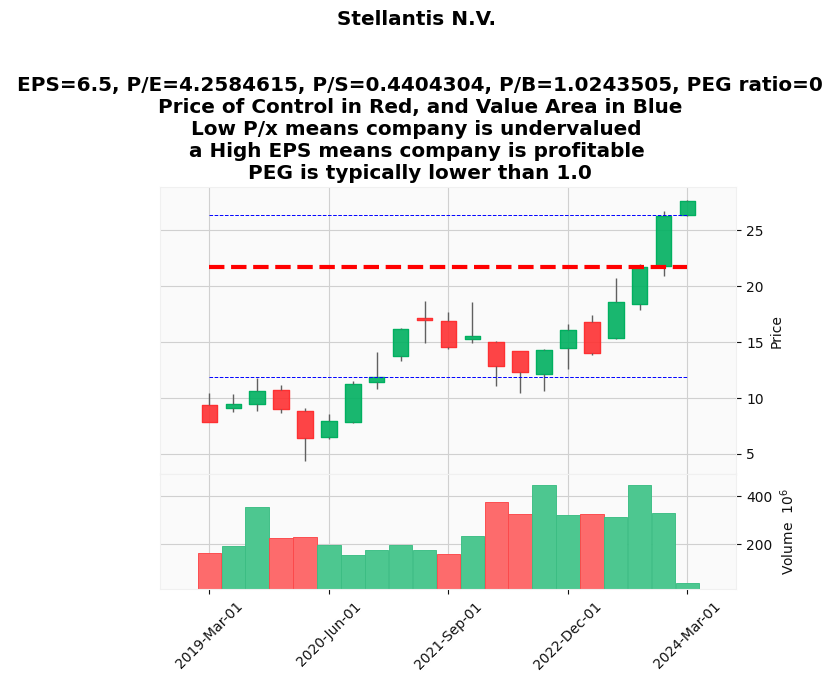

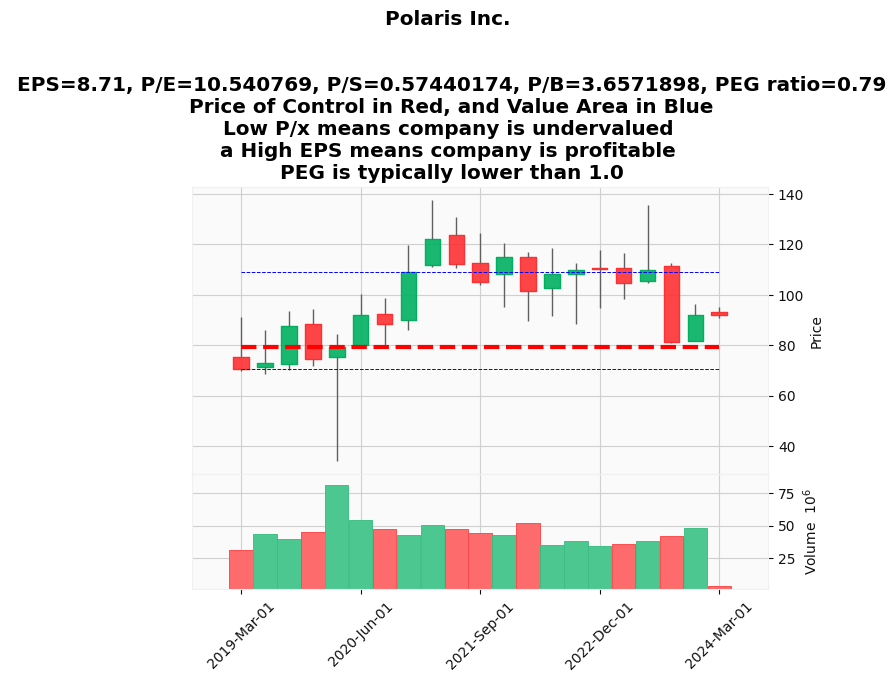

## Sector: Technology

<Figure size 640x480 with 0 Axes>

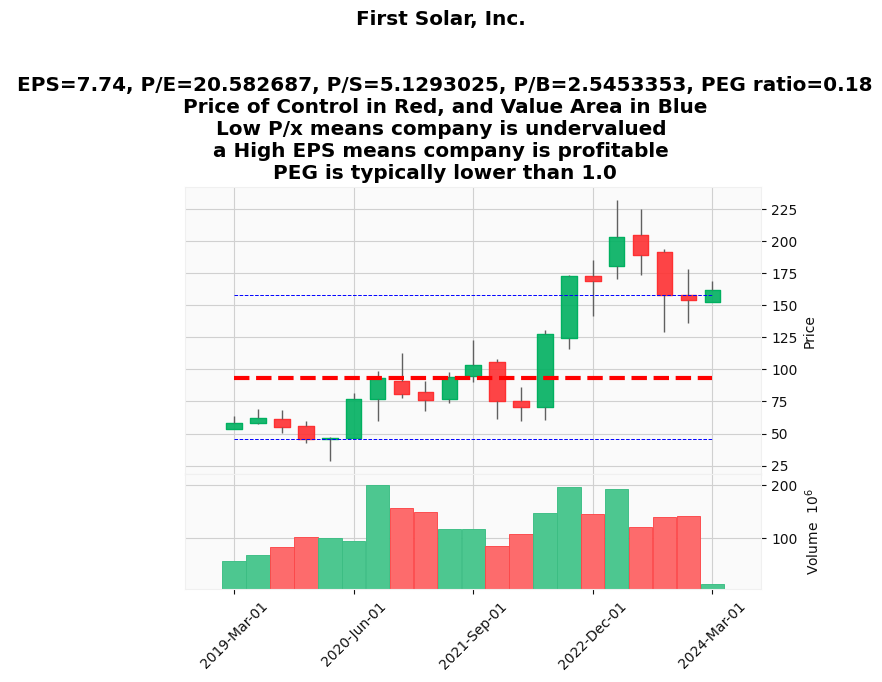

## Sector: Communication Services

<Figure size 640x480 with 0 Axes>

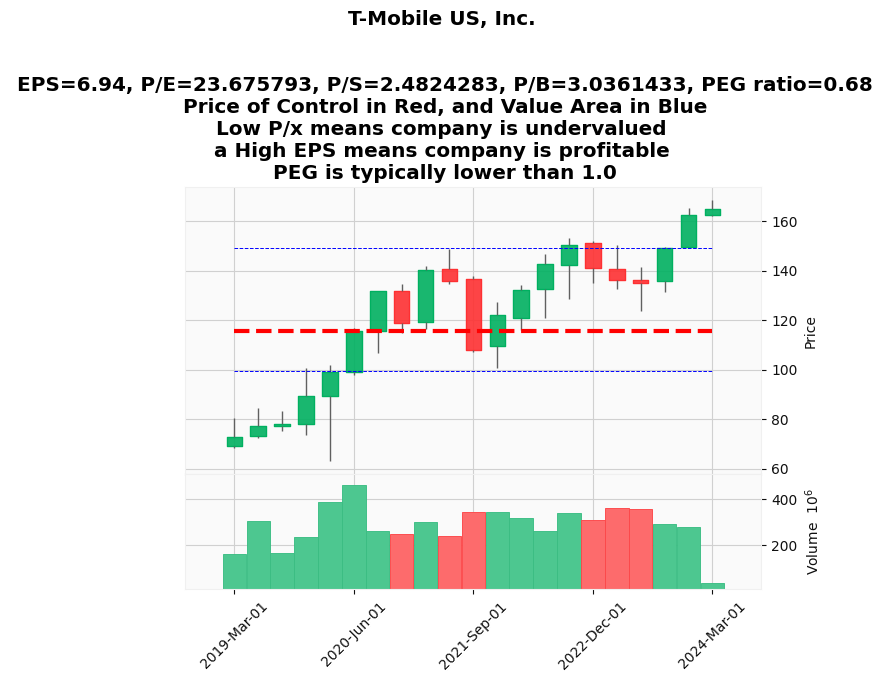

<Figure size 640x480 with 0 Axes>

{'Consumer Cyclical': [yfinance.Ticker object <STLA>, yfinance.Ticker object <PII>], 'Technology': [yfinance.Ticker object <FSLR>], 'Communication Services': [yfinance.Ticker object <TMUS>]}


In [136]:
plot_sector_charts(industries_filtered, start_date_str, end_date_str)
print(industries_filtered)